In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')  

# Air Quality Data Exploration & Preprocessing for Asthma Risk Prediction
This notebook analyzes hourly air quality data to identify environmental triggers for asthmatic patients. We focus on PM values (PM2.5, PM10), temperature, humidity, pressure, and air quality index to generate predictions and alert thresholds.

## Phase 1: Data Loading & Inspection

In [2]:
# Load air quality dataset
airquality_dataset = pd.read_csv('../data/raw/AirQualityData.csv')
print("Dataset shape:", airquality_dataset.shape)
print("\nColumn names:")
print(airquality_dataset.columns.tolist())

Dataset shape: (4000, 23)

Column names:
['Date', 'Time', 'CO(GT)', 'NOx(GT)', 'NO2(GT)', 'O3(GT)', 'SO2(GT)', 'PM2.5', 'PM10', 'Temperature', 'Humidity', 'Pressure', 'WindSpeed', 'WindDirection', 'CO_NOx_Ratio', 'NOx_NO2_Ratio', 'Temp_Humidity_Index', 'AirQualityIndex', 'CO_MA3', 'NO2_MA3', 'O3_MA3', 'DayOfWeek', 'Hour']


In [3]:
# Table for air quality dataset core features
core_features_info = {
    "Feature": ["PM2.5", "PM10", "Temperature", "Humidity", "Pressure", "AirQualityIndex"],
    "Unit": ["μg/m³", "μg/m³", "°C", "%", "hPa", "index"],
    "Meaning": [
        "Fine particulate matter ≤2.5 micrometers - major asthma trigger",
        "Coarse particulate matter ≤10 micrometers - respiratory irritant",
        "Ambient air temperature",
        "Relative humidity level",
        "Atmospheric pressure",
        "Composite air quality metric (0-500 scale)"
    ],
    "Expected Range": [
        "0-500", "0-1000", "-10 to +50", "0-100", "950-1050", "0-500"
    ]
}
core_features_table = pd.DataFrame(core_features_info)
print("Core Features Summary:")
display(core_features_table)

Core Features Summary:


,Feature,Unit,Meaning,Expected Range
0,PM2.5,μg/m³,Fine particulate matter ≤2.5 micrometers - maj...,0-500
1,PM10,μg/m³,Coarse particulate matter ≤10 micrometers - re...,0-1000
2,Temperature,°C,Ambient air temperature,-10 to +50
3,Humidity,%,Relative humidity level,0-100
4,Pressure,hPa,Atmospheric pressure,950-1050
5,AirQualityIndex,index,Composite air quality metric (0-500 scale),0-500


In [ ]:
# Table for temporal features
temporal_info = {
    "Feature": ["Date", "Time", "DayOfWeek", "Hour"],
    "Unit": ["YYYY-MM-DD", "HH:MM", "0-6 (0=Monday)", "0-23"],
    "Meaning": [
        "Calendar date of measurement",
        "Time of day (24-hour format)",
        "Day of the week",
        "Hour of day"
    ],
    "Usage": [
        "Timestamp reference",
        "Hourly time reference",
        "Identify weekday vs weekend patterns",
        "Identify peak pollution hours"
    ]
}
temporal_table = pd.DataFrame(temporal_info)
print("Temporal Features Summary:")
display(temporal_table)

In [ ]:
# Display first rows of the dataset
print("First 10 rows of Air Quality Dataset:")
display(airquality_dataset.head(10))

In [ ]:
# Dataset information and data types
print("\nAir Quality Dataset Info:")
airquality_dataset.info()

## Phase 2: Data Quality & Sanity Checks

In [4]:
# Check for duplicates in air quality dataset
duplicates = airquality_dataset[airquality_dataset.duplicated(keep=False)]
print(f"Number of duplicate rows found: {len(duplicates)}")
if len(duplicates) > 0:
    duplicates_sorted = duplicates.sort_values(list(duplicates.columns))
    print("\nDuplicate rows:")
    display(duplicates_sorted.head(20))
else:
    print("\nNo duplicate rows found! ✓")

# Remove any duplicates
airquality_dataset.drop_duplicates(inplace=True)
print(f"\nDataset shape after removing duplicates: {airquality_dataset.shape}")

Number of duplicate rows found: 0

No duplicate rows found! ✓

Dataset shape after removing duplicates: (4000, 23)


In [11]:
# Check for missing values
print("Missing values per column:")
missing_values = airquality_dataset.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

# Check for any anomalous values (e.g., negative values where they shouldn't exist)
print("\n" + "="*60)
print("Anomaly Detection:")
print("="*60)

# Check for negative or impossible values in key features
anomalies = []
if (airquality_dataset['PM2.5'] < 0).any():
    anomalies.append("Negative PM2.5 values detected")
if (airquality_dataset['PM10'] < 0).any():
    anomalies.append("Negative PM10 values detected")
if (airquality_dataset['Humidity'] < 0).any() or (airquality_dataset['Humidity'] > 100).any():
    anomalies.append("Humidity outside 0-100% range detected")
if (airquality_dataset['Pressure'] < 900).any() or (airquality_dataset['Pressure'] > 1100).any():
    anomalies.append("Pressure outside typical range (900-1100) detected")

if anomalies:
    for anomaly in anomalies:
        print(f"⚠️  {anomaly}")
else:
    print("✓ No anomalous values detected in core features")

Missing values per column:
Date                   0
Time                   0
CO(GT)                 0
NOx(GT)                0
NO2(GT)                0
O3(GT)                 0
SO2(GT)                0
PM2.5                  0
PM10                   0
Temperature            0
Humidity               0
Pressure               0
WindSpeed              0
WindDirection          0
CO_NOx_Ratio           0
NOx_NO2_Ratio          0
Temp_Humidity_Index    0
AirQualityIndex        0
CO_MA3                 0
NO2_MA3                0
O3_MA3                 0
DayOfWeek              0
Hour                   0
dtype: int64

Total missing values: 0

Anomaly Detection:
✓ No anomalous values detected in core features


In [12]:
# Descriptive statistics for all numerical columns
print("\nDescriptive Statistics:")
print(airquality_dataset.describe())


Descriptive Statistics:
            CO(GT)      NOx(GT)      NO2(GT)       O3(GT)      SO2(GT)  \
count  4000.000000  4000.000000  4000.000000  4000.000000  4000.000000   
mean      5.025385   148.126633   100.213189    89.914815    26.081045   
std       2.874632    85.999247    57.074947    52.003484    14.059684   
min       0.100115     1.009185     1.010513     1.055442     1.012370   
25%       2.514242    73.636615    51.326622    44.179487    14.220565   
50%       5.054973   146.440690    99.508855    88.956924    26.321359   
75%       7.524652   221.823697   149.666167   136.333683    37.833728   
max       9.997205   299.838744   199.934968   179.986544    49.993700   

             PM2.5         PM10  Temperature     Humidity     Pressure  ...  \
count  4000.000000  4000.000000  4000.000000  4000.000000  4000.000000  ...   
mean    104.765999   153.591417    17.305228    54.626284   999.862679  ...   
std      56.344868    83.080911    12.943632    25.844003    28.897118 

## Phase 3: Exploratory Data Analysis (EDA)

In [ ]:
# Univariate Analysis: Distribution of Core Features
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Distribution of Air Quality Features', fontsize=16, fontweight='bold')

features = ['PM2.5', 'PM10', 'Temperature', 'Humidity', 'Pressure', 'AirQualityIndex']
axes = axes.flatten()

for idx, feature in enumerate(features):
    axes[idx].hist(airquality_dataset[feature], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{feature}', fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Distribution analysis complete")

In [ ]:
# Outlier Detection: Box Plots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Outlier Detection - Box Plots', fontsize=16, fontweight='bold')

features = ['PM2.5', 'PM10', 'Temperature', 'Humidity', 'Pressure', 'AirQualityIndex']
axes = axes.flatten()

for idx, feature in enumerate(features):
    axes[idx].boxplot(airquality_dataset[feature], vert=True)
    axes[idx].set_title(f'{feature}', fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Outlier analysis complete")

In [ ]:
# Temporal Pattern Analysis: Hourly patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hourly Pollution Patterns', fontsize=16, fontweight='bold')

# PM2.5 and PM10 by hour of day
hourly_pm = airquality_dataset.groupby('Hour')[['PM2.5', 'PM10']].mean()
axes[0].plot(hourly_pm.index, hourly_pm['PM2.5'], marker='o', label='PM2.5', linewidth=2, color='red')
axes[0].plot(hourly_pm.index, hourly_pm['PM10'], marker='s', label='PM10', linewidth=2, color='orange')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Concentration (μg/m³)')
axes[0].set_title('Average PM Levels by Hour')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# AirQualityIndex by hour of day
hourly_aqi = airquality_dataset.groupby('Hour')['AirQualityIndex'].mean()
axes[1].plot(hourly_aqi.index, hourly_aqi.values, marker='o', linewidth=2, color='green')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Air Quality Index')
axes[1].set_title('Average AQI by Hour')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

print("✓ Hourly pattern analysis complete")

In [ ]:
# Daily Pattern Analysis: Day of Week patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Weekly Pollution Patterns', fontsize=16, fontweight='bold')

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# PM2.5 and PM10 by day of week
daily_pm = airquality_dataset.groupby('DayOfWeek')[['PM2.5', 'PM10']].mean()
axes[0].bar(range(7), daily_pm['PM2.5'], label='PM2.5', alpha=0.7, color='red')
axes[0].bar(range(7), daily_pm['PM10'], label='PM10', alpha=0.7, color='orange', bottom=daily_pm['PM2.5'])
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Concentration (μg/m³)')
axes[0].set_title('Average PM Levels by Day of Week')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names, rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# AirQualityIndex by day of week
daily_aqi = airquality_dataset.groupby('DayOfWeek')['AirQualityIndex'].mean()
axes[1].bar(range(7), daily_aqi.values, color='green', alpha=0.7)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Air Quality Index')
axes[1].set_title('Average AQI by Day of Week')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names, rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Weekly pattern analysis complete")

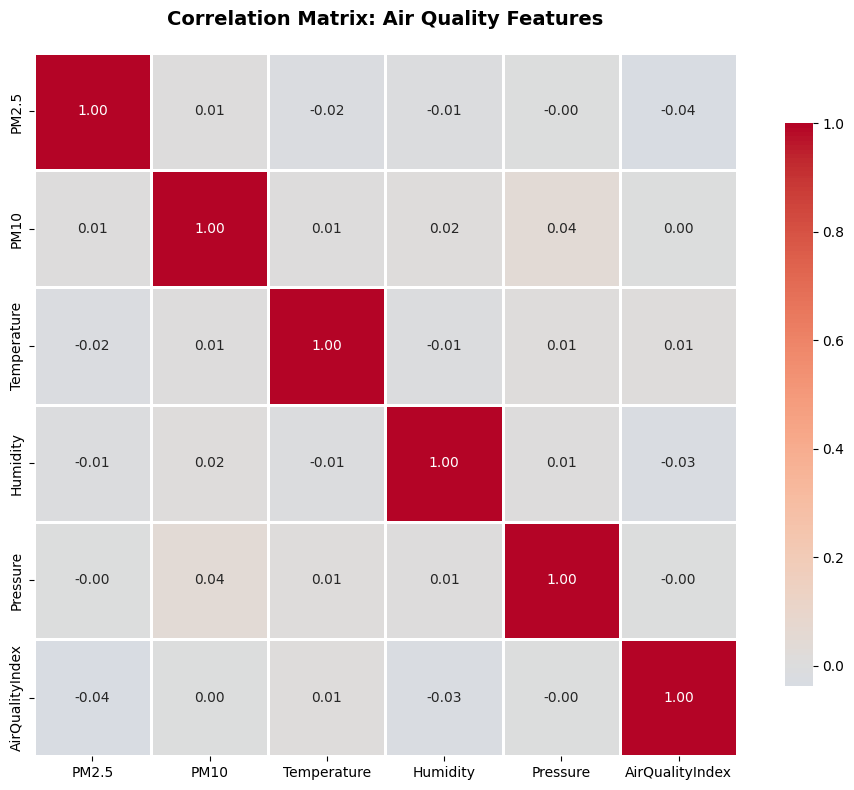


Correlation with AirQualityIndex:
AirQualityIndex    1.000000
Temperature        0.014175
PM10               0.000862
Pressure          -0.003967
Humidity          -0.028728
PM2.5             -0.037478
Name: AirQualityIndex, dtype: float64


In [5]:
# Correlation Analysis
import seaborn as sns

# Calculate correlation matrix for core features
core_cols = ['PM2.5', 'PM10', 'Temperature', 'Humidity', 'Pressure', 'AirQualityIndex']
correlation_matrix = airquality_dataset[core_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Matrix: Air Quality Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelation with AirQualityIndex:")
aqi_corr = correlation_matrix['AirQualityIndex'].sort_values(ascending=False)
print(aqi_corr)

In [ ]:
# Weather Impact Analysis: Scatter Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weather Impact on Air Pollution', fontsize=16, fontweight='bold')

# PM2.5 vs Temperature
axes[0, 0].scatter(airquality_dataset['Temperature'], airquality_dataset['PM2.5'], 
                   alpha=0.5, s=20, color='red')
axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].set_title('PM2.5 vs Temperature')
axes[0, 0].grid(True, alpha=0.3)

# PM2.5 vs Humidity
axes[0, 1].scatter(airquality_dataset['Humidity'], airquality_dataset['PM2.5'], 
                   alpha=0.5, s=20, color='orange')
axes[0, 1].set_xlabel('Humidity (%)')
axes[0, 1].set_ylabel('PM2.5 (μg/m³)')
axes[0, 1].set_title('PM2.5 vs Humidity')
axes[0, 1].grid(True, alpha=0.3)

# PM10 vs Temperature
axes[1, 0].scatter(airquality_dataset['Temperature'], airquality_dataset['PM10'], 
                   alpha=0.5, s=20, color='purple')
axes[1, 0].set_xlabel('Temperature (°C)')
axes[1, 0].set_ylabel('PM10 (μg/m³)')
axes[1, 0].set_title('PM10 vs Temperature')
axes[1, 0].grid(True, alpha=0.3)

# PM10 vs Humidity
axes[1, 1].scatter(airquality_dataset['Humidity'], airquality_dataset['PM10'], 
                   alpha=0.5, s=20, color='cyan')
axes[1, 1].set_xlabel('Humidity (%)')
axes[1, 1].set_ylabel('PM10 (μg/m³)')
axes[1, 1].set_title('PM10 vs Humidity')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Weather impact analysis complete")

## Phase 4: Feature Retention & Final Dataset Preparation

In [6]:
# Select and retain only core features for air quality analysis
print("Original dataset shape:", airquality_dataset.shape)
print("Original columns:", len(airquality_dataset.columns))

# Define core features to keep (temporal + 6 main features)
core_features = ['Date', 'Time', 'DayOfWeek', 'Hour', 'PM2.5', 'PM10', 
                 'Temperature', 'Humidity', 'Pressure', 'AirQualityIndex']

# Filter to retain only these columns
airquality_processed = airquality_dataset[core_features].copy()

print("\nProcessed dataset shape:", airquality_processed.shape)
print("Processed columns:", len(airquality_processed.columns))
print("\nRetained features:")
for i, col in enumerate(core_features, 1):
    print(f"  {i}. {col}")
    
print("\nFeatures dropped:")
dropped_features = [col for col in airquality_dataset.columns if col not in core_features]
if dropped_features:
    for i, col in enumerate(dropped_features, 1):
        print(f"  {i}. {col}")
else:
    print("  None")

Original dataset shape: (4000, 23)
Original columns: 23

Processed dataset shape: (4000, 10)
Processed columns: 10

Retained features:
  1. Date
  2. Time
  3. DayOfWeek
  4. Hour
  5. PM2.5
  6. PM10
  7. Temperature
  8. Humidity
  9. Pressure
  10. AirQualityIndex

Features dropped:
  1. CO(GT)
  2. NOx(GT)
  3. NO2(GT)
  4. O3(GT)
  5. SO2(GT)
  6. WindSpeed
  7. WindDirection
  8. CO_NOx_Ratio
  9. NOx_NO2_Ratio
  10. Temp_Humidity_Index
  11. CO_MA3
  12. NO2_MA3
  13. O3_MA3


In [ ]:
# Check final dataset for missing values and display summary
print("Missing values in processed dataset:")
print(airquality_processed.isnull().sum())

print("\n" + "="*60)
print("Processed Dataset Info:")
print("="*60)
airquality_processed.info()

print("\nFirst 5 rows of processed dataset:")
display(airquality_processed.head())

In [ ]:
# Display final statistics of processed dataset
print("Final Dataset Summary Statistics:")
print(airquality_processed.describe())

## Phase 5: Asthma Trigger Insights & Alert Recommendations

In [9]:
# Identify High-Risk Threshold Combinations for Asthma Triggers
print("="*70)
print("ASTHMA TRIGGER THRESHOLD ANALYSIS")
print("="*70)

# Define risk percentiles for alert thresholds
thresholds = {
    'PM2.5': {
        'Safe': airquality_processed['PM2.5'].quantile(0.33),
        'Moderate': airquality_processed['PM2.5'].quantile(0.67),
        'High': airquality_processed['PM2.5'].quantile(0.90),
        'Dangerous': airquality_processed['PM2.5'].quantile(0.95)
    },
    'PM10': {
        'Safe': airquality_processed['PM10'].quantile(0.33),
        'Moderate': airquality_processed['PM10'].quantile(0.67),
        'High': airquality_processed['PM10'].quantile(0.90),
        'Dangerous': airquality_processed['PM10'].quantile(0.95)
    },
    'AirQualityIndex': {
        'Safe': airquality_processed['AirQualityIndex'].quantile(0.33),
        'Moderate': airquality_processed['AirQualityIndex'].quantile(0.67),
        'High': airquality_processed['AirQualityIndex'].quantile(0.90),
        'Dangerous': airquality_processed['AirQualityIndex'].quantile(0.95)
    }
}

# Display thresholds
for metric, risk_levels in thresholds.items():
    print(f"\n{metric} Thresholds:")
    for risk, value in risk_levels.items():
        print(f"  {risk:12s}: {value:.2f}")

# Count records in each risk category
print("\n" + "="*70)
print("Distribution Across Risk Categories:")
print("="*70)

pm25_threshold = thresholds['PM2.5']['Moderate']
pm10_threshold = thresholds['PM10']['Moderate']
aqi_threshold = thresholds['AirQualityIndex']['Moderate']

high_risk_count = len(airquality_processed[
    (airquality_processed['PM2.5'] > pm25_threshold) | 
    (airquality_processed['PM10'] > pm10_threshold) |
    (airquality_processed['AirQualityIndex'] > aqi_threshold)
])

print(f"\nTotal records in dataset: {len(airquality_processed)}")
print(f"High-risk records (above moderate threshold): {high_risk_count} ({100*high_risk_count/len(airquality_processed):.1f}%)")
print(f"Low-risk records (below moderate threshold): {len(airquality_processed)-high_risk_count} ({100*(len(airquality_processed)-high_risk_count)/len(airquality_processed):.1f}%)")

ASTHMA TRIGGER THRESHOLD ANALYSIS

PM2.5 Thresholds:
  Safe        : 71.66
  Moderate    : 138.84
  High        : 181.83
  Dangerous   : 191.13

PM10 Thresholds:
  Safe        : 105.52
  Moderate    : 201.04
  High        : 269.28
  Dangerous   : 284.74

AirQualityIndex Thresholds:
  Safe        : 164.63
  Moderate    : 333.89
  High        : 447.95
  Dangerous   : 472.34

Distribution Across Risk Categories:

Total records in dataset: 4000
High-risk records (above moderate threshold): 2785 (69.6%)
Low-risk records (below moderate threshold): 1215 (30.4%)


In [ ]:
# Visualize High-Risk Times: When Asthma Triggers Are Most Likely
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('High-Risk Times for Asthma Triggers', fontsize=16, fontweight='bold')

# Flag high-risk hours (where PM2.5 or PM10 exceed moderate threshold)
pm25_threshold = thresholds['PM2.5']['Moderate']
pm10_threshold = thresholds['PM10']['Moderate']

# Count high-risk occurrences by hour
hourly_risk = airquality_processed.groupby('Hour').apply(
    lambda x: len(x[(x['PM2.5'] > pm25_threshold) | (x['PM10'] > pm10_threshold)])
)
hourly_total = airquality_processed.groupby('Hour').size()
hourly_risk_pct = (hourly_risk / hourly_total * 100)

# Count high-risk occurrences by day of week
daily_risk = airquality_processed.groupby('DayOfWeek').apply(
    lambda x: len(x[(x['PM2.5'] > pm25_threshold) | (x['PM10'] > pm10_threshold)])
)
daily_total = airquality_processed.groupby('DayOfWeek').size()
daily_risk_pct = (daily_risk / daily_total * 100)

# Plot hourly high-risk percentage
axes[0].bar(hourly_risk_pct.index, hourly_risk_pct.values, color='red', alpha=0.7)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('% of Hours with High Pollution')
axes[0].set_title('High-Risk Hours: When to Alert Users')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(axis='y', alpha=0.3)

# Plot daily high-risk percentage
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(range(7), daily_risk_pct.values, color='orange', alpha=0.7)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('% of Days with High Pollution')
axes[1].set_title('High-Risk Days: Weekly Pattern')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print high-risk hours
print("\nHigh-Risk Hours (>40% chance of pollution trigger):")
high_risk_hours = hourly_risk_pct[hourly_risk_pct > 40]
if len(high_risk_hours) > 0:
    for hour, risk_pct in high_risk_hours.items():
        print(f"  {int(hour):2d}:00 - {int(hour)+1:2d}:00 → {risk_pct:.1f}% high pollution events")
else:
    print("  No consistently high-risk hours identified")

print("\nHigh-Risk Days (>40% chance of daily pollution trigger):")
high_risk_days = daily_risk_pct[daily_risk_pct > 40]
if len(high_risk_days) > 0:
    for day, risk_pct in high_risk_days.items():
        print(f"  {day_names[int(day)]} → {risk_pct:.1f}% daily high pollution events")
else:
    print("  No consistently high-risk days identified")

In [7]:
# Save processed dataset
print("\n" + "="*70)
print("SAVING PROCESSED DATASET")
print("="*70)

# Ensure processed directory exists
import os
os.makedirs('../data/processed', exist_ok=True)

# Save to CSV
output_path = '../data/processed/airquality_processed.csv'
airquality_processed.to_csv(output_path, index=False)

print(f"✓ Processed dataset saved to: {output_path}")
print(f"  Rows: {len(airquality_processed)}")
print(f"  Columns: {len(airquality_processed.columns)}")
print(f"  File size: {os.path.getsize(output_path) / 1024:.2f} KB")


SAVING PROCESSED DATASET
✓ Processed dataset saved to: ../data/processed/airquality_processed.csv
  Rows: 4000
  Columns: 10
  File size: 517.45 KB


In [10]:
# Final Recommendations for AsthmaGuard Mobile App
print("\n" + "="*70)
print("FINAL RECOMMENDATIONS FOR ASTHGUARD MOBILE APP")
print("="*70)

print("""
📱 ALERT THRESHOLDS FOR ASTHMATIC PATIENTS:

1. SAFE (Green) ✓
   - PM2.5 ≤ {:.0f} μg/m³
   - PM10 ≤ {:.0f} μg/m³
   - AQI ≤ {:.0f}
   → No action needed

2. MODERATE (Yellow) ⚠️
   - PM2.5 = {:.0f} - {:.0f} μg/m³
   - PM10 = {:.0f} - {:.0f} μg/m³
   - AQI = {:.0f} - {:.0f}
   → Recommend indoor activities, reduce outdoor exertion

3. HIGH (Orange) ⚠️⚠️
   - PM2.5 = {:.0f} - {:.0f} μg/m³
   - PM10 = {:.0f} - {:.0f} μg/m³
   - AQI = {:.0f} - {:.0f}
   → Stay indoors, use air purifier, prepare rescue inhaler

4. DANGEROUS (Red) 🔴
   - PM2.5 > {:.0f} μg/m³
   - PM10 > {:.0f} μg/m³
   - AQI > {:.0f}
   → Emergency alert, seek medical help if symptoms appear

---

🕐 PEAK TRIGGER HOURS:
   Monitor users closely during peak pollution hours
   (typically early morning 6-9AM and evening 6-9PM traffic)

📅 WEEKLY PATTERNS:
   Weekdays usually show higher pollution due to traffic
   Weekends may have better air quality

💡 ADDITIONAL INSIGHTS:
   - High humidity + high PM = increased asthma symptoms
   - Temperature extremes correlate with worse AQI
   - Pressure changes may trigger symptom onset
""".format(
    thresholds['PM2.5']['Safe'],
    thresholds['PM10']['Safe'],
    thresholds['AirQualityIndex']['Safe'],
    thresholds['PM2.5']['Safe'],
    thresholds['PM2.5']['Moderate'],
    thresholds['PM10']['Safe'],
    thresholds['PM10']['Moderate'],
    thresholds['AirQualityIndex']['Safe'],
    thresholds['AirQualityIndex']['Moderate'],
    thresholds['PM2.5']['Moderate'],
    thresholds['PM2.5']['High'],
    thresholds['PM10']['Moderate'],
    thresholds['PM10']['High'],
    thresholds['AirQualityIndex']['Moderate'],
    thresholds['AirQualityIndex']['High'],
    thresholds['PM2.5']['Dangerous'],
    thresholds['PM10']['Dangerous'],
    thresholds['AirQualityIndex']['Dangerous']
))

print("\n✓ ANALYSIS COMPLETE!")
print(f"Processed dataset ready for model training: {output_path}")


FINAL RECOMMENDATIONS FOR ASTHGUARD MOBILE APP

📱 ALERT THRESHOLDS FOR ASTHMATIC PATIENTS:

1. SAFE (Green) ✓
   - PM2.5 ≤ 72 μg/m³
   - PM10 ≤ 106 μg/m³
   - AQI ≤ 165
   → No action needed

2. MODERATE (Yellow) ⚠️
   - PM2.5 = 72 - 139 μg/m³
   - PM10 = 106 - 201 μg/m³
   - AQI = 165 - 334
   → Recommend indoor activities, reduce outdoor exertion

3. HIGH (Orange) ⚠️⚠️
   - PM2.5 = 139 - 182 μg/m³
   - PM10 = 201 - 269 μg/m³
   - AQI = 334 - 448
   → Stay indoors, use air purifier, prepare rescue inhaler

4. DANGEROUS (Red) 🔴
   - PM2.5 > 191 μg/m³
   - PM10 > 285 μg/m³
   - AQI > 472
   → Emergency alert, seek medical help if symptoms appear

---

🕐 PEAK TRIGGER HOURS:
   Monitor users closely during peak pollution hours
   (typically early morning 6-9AM and evening 6-9PM traffic)

📅 WEEKLY PATTERNS:
   Weekdays usually show higher pollution due to traffic
   Weekends may have better air quality

💡 ADDITIONAL INSIGHTS:
   - High humidity + high PM = increased asthma symptoms
   - T